In [45]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd

heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)

print(df.head())
print(df.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  
3  0.0   3.0    0  
4  0.0   3.0    0  
(303, 14)


In [46]:
# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [48]:
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [49]:
df["ca"] = df["ca"].fillna(df["ca"].mode()[0])
df["thal"] = df["thal"].fillna(df["thal"].mode()[0])

In [50]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [51]:
df["num"] = (df["num"] > 0).astype(int)

In [52]:
df["num"].value_counts()


,count
num,
0,164
1,139


In [53]:
X = df.drop("num", axis=1)
y = df["num"]

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [55]:
from sklearn.linear_model import LogisticRegression

In [56]:
model = LogisticRegression(max_iter=1000)

In [57]:
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [58]:
y_pred = model.predict(X_test)

In [59]:
print(y_pred)

[0 1 0 0 1 0 0 0 1 0 1 0 0 1 1 1 1 0 1 1 1 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1 0
 0 0 1 1 1 1 1 0 0 1 0 1 0 0 1 1 0 0 1 1 1 0 0 1]


In [60]:
from sklearn.metrics import accuracy_score

In [61]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8688524590163934


In [62]:
y_prob = model.predict_proba(X_test)[:, 1]

In [63]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", roc_auc)

ROC AUC: 0.9523809523809524


In [64]:
from sklearn.metrics import confusion_matrix

In [65]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[27  6]
 [ 2 26]]


In [66]:
!pip install wfdb

In [67]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np

In [68]:
record = wfdb.rdrecord('100', pn_dir='mitdb') # Load ECG record

In [69]:
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')
# Load annotations

In [70]:
print(record.p_signal.shape)

(650000, 2)


In [71]:
print("Sampling frequency:", record.fs) # Sampling frequency

Sampling frequency: 360


In [72]:
ecg = record.p_signal[:, 0] # Extract first ECG channel

In [73]:
print(ecg[:10])

[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]


In [74]:
fs = record.fs  # Plot first 10 seconds

start = 0
duration = 10

end = start + int(duration * fs)

time = np.arange(start, end) / fs

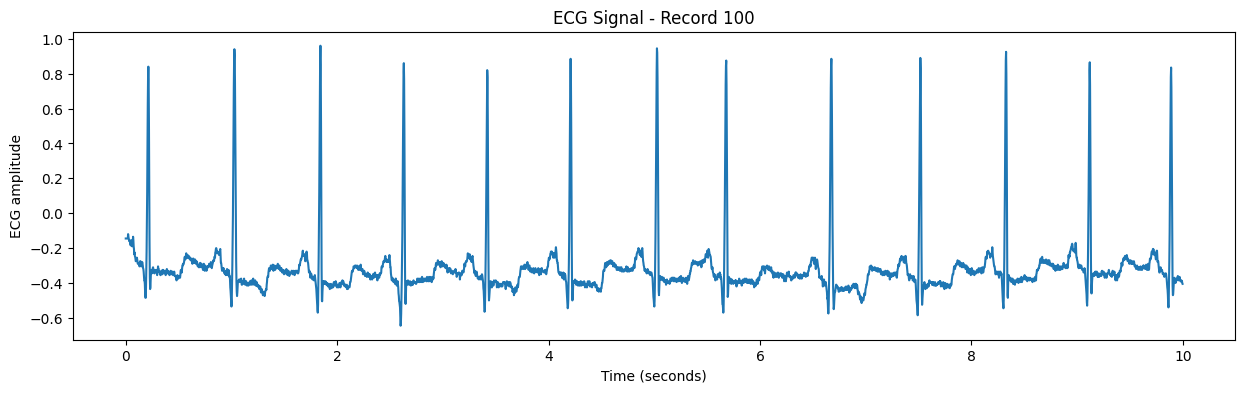

In [75]:
plt.figure(figsize=(15, 4))

plt.plot(time, ecg[start:end])

plt.xlabel("Time (seconds)")
plt.ylabel("ECG amplitude")
plt.title("ECG Signal - Record 100")

plt.show()

In [76]:
print(annotation.sample[:20])

[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]


In [77]:
beat_times = annotation.sample / fs

In [78]:
print(annotation.symbol[:20])

['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


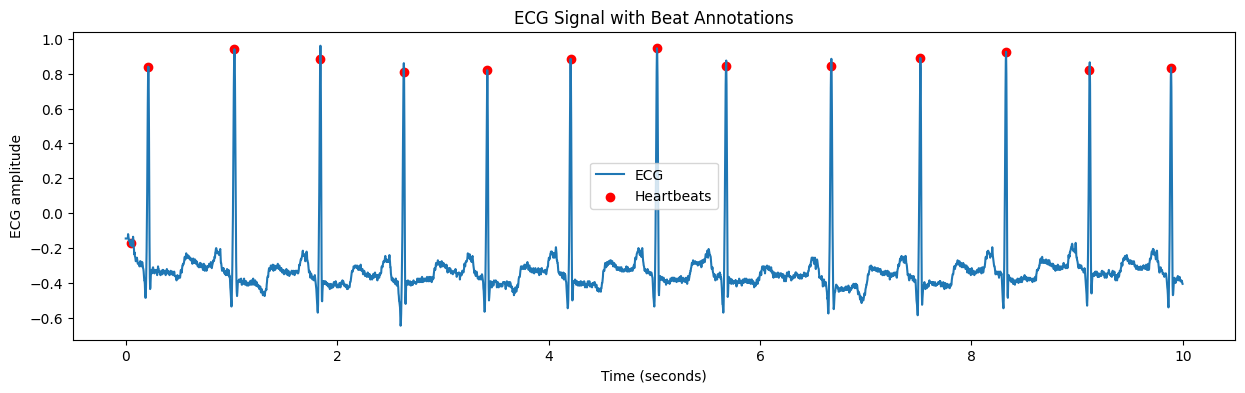

In [79]:
plt.figure(figsize=(15, 4))

plt.plot(time, ecg[start:end], label="ECG")

# Select annotations within our 10-second segment
mask = (beat_times >= start / fs) & (beat_times < end / fs)

beat_samples = annotation.sample[mask]
beat_times_segment = beat_times[mask]

# ECG values at beat locations
beat_values = ecg[beat_samples]

plt.scatter(
    beat_times_segment,
    beat_values,
    color="red",
    label="Heartbeats"
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG amplitude")
plt.title("ECG Signal with Beat Annotations")
plt.legend()

plt.show()

In [80]:
beat_samples = annotation.sample
beat_times = beat_samples / fs

In [81]:
rr_intervals = np.diff(beat_times)

In [82]:
print(rr_intervals[:10])

[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]


In [83]:
mean_rr = np.mean(rr_intervals)

print("Mean RR interval:", mean_rr, "seconds")

Mean RR interval: 0.7943161265092633 seconds


In [84]:
heart_rate = 60 / mean_rr

print("Average heart rate:", heart_rate, "BPM")


Average heart rate: 75.536676138855 BPM


In [85]:
sdnn = np.std(rr_intervals)

print("SDNN:", sdnn, "seconds")

SDNN: 0.050584340991449706 seconds


In [86]:
print("Minimum RR:", np.min(rr_intervals))
print("Maximum RR:", np.max(rr_intervals))

Minimum RR: 0.16388888888888886
Maximum RR: 1.130555555555702


In [87]:
# Textual Data Demonstration - Simple NLP

# Sample clinical note
patient_note = """
The patient is a 55 year old male who reports chest pain and shortness of breath.
The chest pain started two hours ago and becomes worse during physical activity.
The patient also reports dizziness and sweating. No previous history of heart disease.
"""

# Convert text to lowercase
text = patient_note.lower()

# Tokenize words
import re
from collections import Counter

tokens = re.findall(r'\b\w+\b', text)

print("Tokens:")
print(tokens)

# Word frequency
word_frequency = Counter(tokens)

print("\nWord Frequency:")
print(word_frequency)

# Display most common words
print("\nMost Common Words:")
print(word_frequency.most_common(10))

# Extract key clinical terms
key_terms = [
    "chest pain",
    "shortness of breath",
    "dizziness",
    "sweating",
    "heart disease",
    "physical activity"
]

found_terms = []

for term in key_terms:
    if term in text:
        found_terms.append(term)

print("\nKey Clinical Terms:")
print(found_terms)

Tokens:
['the', 'patient', 'is', 'a', '55', 'year', 'old', 'male', 'who', 'reports', 'chest', 'pain', 'and', 'shortness', 'of', 'breath', 'the', 'chest', 'pain', 'started', 'two', 'hours', 'ago', 'and', 'becomes', 'worse', 'during', 'physical', 'activity', 'the', 'patient', 'also', 'reports', 'dizziness', 'and', 'sweating', 'no', 'previous', 'history', 'of', 'heart', 'disease']

Word Frequency:
Counter({'the': 3, 'and': 3, 'patient': 2, 'reports': 2, 'chest': 2, 'pain': 2, 'of': 2, 'is': 1, 'a': 1, '55': 1, 'year': 1, 'old': 1, 'male': 1, 'who': 1, 'shortness': 1, 'breath': 1, 'started': 1, 'two': 1, 'hours': 1, 'ago': 1, 'becomes': 1, 'worse': 1, 'during': 1, 'physical': 1, 'activity': 1, 'also': 1, 'dizziness': 1, 'sweating': 1, 'no': 1, 'previous': 1, 'history': 1, 'heart': 1, 'disease': 1})

Most Common Words:
[('the', 3), ('and', 3), ('patient', 2), ('reports', 2), ('chest', 2), ('pain', 2), ('of', 2), ('is', 1), ('a', 1), ('55', 1)]

Key Clinical Terms:
['chest pain', 'shortness 

Format: WEBP
Size: (620, 400)
Mode: RGB


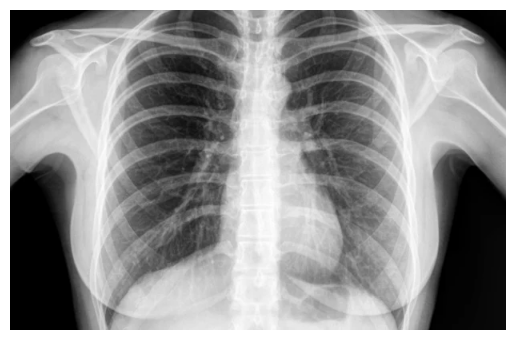

In [90]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("/content/Chest_XRay.webp")

print("Format:", image.format)
print("Size:", image.size)
print("Mode:", image.mode)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [110]:
resized_image = image.resize((250,250))

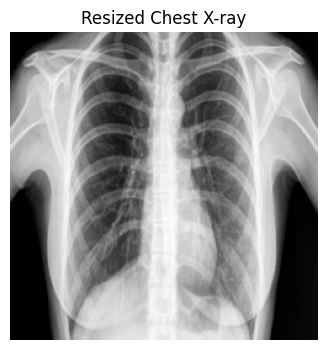

In [111]:
plt.figure(figsize=(4, 4))

plt.imshow(resized_image, cmap="gray")
plt.axis("off")
plt.title("Resized Chest X-ray")

plt.show()


## Integration Discussion

Heart disease prediction can be improved by combining different types of patient data.

### 1. Tabular Data

The tabular dataset contains patient information such as:

- Age
- Sex
- Chest pain type
- Blood pressure
- Cholesterol
- Maximum heart rate
- Exercise-induced angina

A machine learning model can use these features to estimate the patient's risk of heart disease.

### 2. ECG-Derived Features

ECG signals provide information about the electrical activity of the heart. Instead of directly using the entire ECG signal, useful features can be extracted, such as:

- Average heart rate
- RR intervals
- Heart-rate variability (HRV)
- Mean RR interval
- SDNN
- Beat-to-beat variations

These ECG-derived features can provide additional information about the patient's cardiac condition that may not be present in the tabular data.

### 3. Clinical Text Notes

Clinical notes can provide additional context about the patient's symptoms and medical history.

For example, a note might mention:

- Chest pain
- Shortness of breath
- Dizziness
- Sweating
- Pain during physical activity
- Previous heart problems

Simple NLP techniques can extract important terms or features from these notes.

### 4. Future Fused Model

In a future system, all three data types could be combined into a single model:

**Tabular Data → Patient Risk Features**

**ECG Signal → ECG-Derived Features**

**Clinical Notes → Text/NLP Features**

These features could then be combined and given to a machine learning model:

**Tabular Features + ECG Features + Text Features → Fused Model → Heart Disease Risk Prediction**

This multimodal approach could provide a more complete view of the patient because it combines structured patient information, physiological heart signals, and clinical symptoms.

The tabular data provides general risk factors, ECG features provide information about heart activity, and clinical text provides additional information about symptoms and medical history. Combining these sources could potentially improve the accuracy and usefulness of heart disease risk prediction.